In [9]:
from itertools import product
import numpy as np
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector, Operator, SparsePauliOp
from qiskit_aer import AerSimulator
import os
from qiskit.visualization import circuit_drawer
import argparse
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeMarrakesh
import pandas as pd
from scipy.linalg import expm
from dotenv import load_dotenv
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, SamplerV2
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

In [10]:
def get_QPA_circuit_1(k, LAMBDA):
    # Three control qubit
    cr = ClassicalRegister(2*k+3, name='control') #Will only Measure q3
    qr_all = QuantumRegister(3*k + 3)
    
    # Initialize quantum circuit
    qc = QuantumCircuit(qr_all, cr)

    rng = np.random.default_rng()

    reg_ranges = [range(3, 3 + k), range(3+ k, 3+2 * k), range(3+2 * k, 3+3 * k)]
    pauli_strs = ['i', 'x', 'y', 'z']

    for reg in reg_ranges:
        if rng.random() < LAMBDA:
            paulis = rng.choice(pauli_strs, size=k)
            for q, p in zip(reg, paulis):
                if p == 'x':
                    qc.x(q)
                elif p == 'y':
                    qc.y(q)
                elif p == 'z':
                    qc.z(q)
    
    # Single QPA sequence
    qc.h(0)
    for i in range(k):
            qc.cswap(0, i+3, i+k+3)  # Control qubit 0, target q1 and q2
    qc.h(0)
    qc.measure(0,cr[0])
    qc.measure(1,cr[1])
    qc.measure(2,cr[2])
    for i in range(k): #Measure Q2
        qc.measure(3+k+i,cr[3+i])
    for i in range(k): #Measure Q3
        qc.measure(3+2*k+i,cr[3+k+i])
    return qc

Using IBM Sampler


/tmp/ipykernel_1795876/3920963596.py:7: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService(channel="ibm_quantum", instance='research-credits/100698/main', token=token)
/home/caiosiq/.conda/envs/qpa_env/lib/python3.10/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1129: UserWarning: IBM Quantum Platform is moving, and this version will be sunset on July 1. To get started on the new platform, read the migration guide at https://docs.quantum.ibm.com/migration-guides/classic-iqp-to-cloud-iqp
  warnings.warn(warning_message)


d1r706rzeebg0081ske0


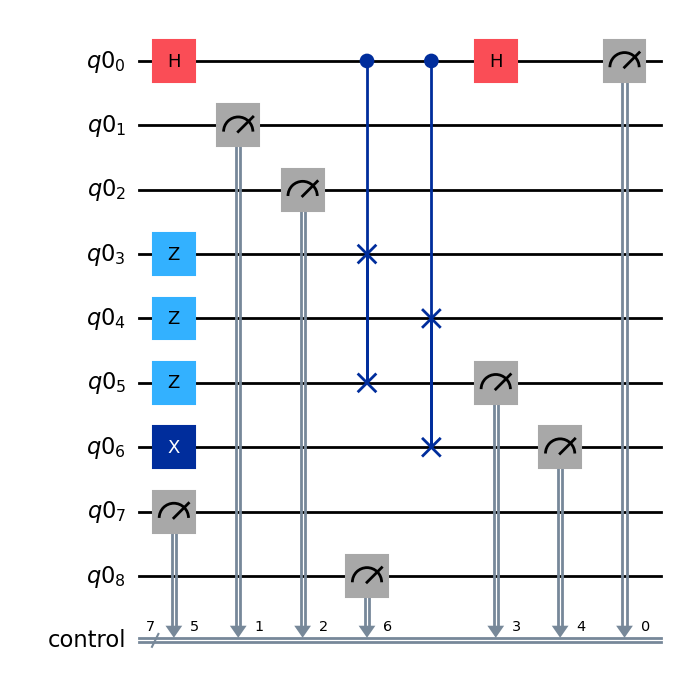

In [11]:
def submit_pauli_job(qc_list, shots, sampler, backend):
    qc_transpiled_list = transpile(qc_list, backend=backend, optimization_level=3)
    return sampler.run(qc_transpiled_list, shots=shots)
print('Using IBM Sampler')
load_dotenv()
token = os.getenv("IBM_QUANTUM_TOKEN")
service = QiskitRuntimeService(channel="ibm_quantum", instance='research-credits/100698/main', token=token)
backend = service.backend("ibm_marrakesh")
sampler = SamplerV2(mode=backend)

qc_list = [get_QPA_circuit_1(2,0.5) for _ in range(100)]
shots = 10
job = submit_pauli_job(qc_list, shots, sampler, backend)
id = job.job_id()
print(id)
display(qc_list[0].draw(output='mpl'))


In [ ]:
result = service.job(id).result()

## IBM Documentation tests

### Estimator Hello World

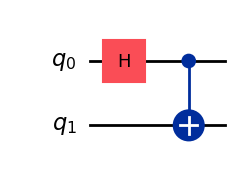

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
# Create a new circuit with two qubits
qc = QuantumCircuit(2)
 
# Add a Hadamard gate to qubit 0
qc.h(0)
 
# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
 
# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

In [4]:
# Set up six different observables.
 
observables_labels = ["IZ", "IX", "ZI", "XI", "ZZ", "XX"]
observables = [SparsePauliOp(label) for label in observables_labels]

/tmp/ipykernel_1795876/3257002098.py:3: DeprecationWarning: The "ibm_quantum" channel option is deprecated and will be sunset on 1 July. After this date, "ibm_cloud", "ibm_quantum_platform", and "local" will be the only valid channels. Open Plan users should migrate now.  All other users should review the migration guide (https://quantum.cloud.ibm.com/docs/migration-guides/classic-iqp-to-cloud-iqp)to learn when to migrate.
  service = QiskitRuntimeService()


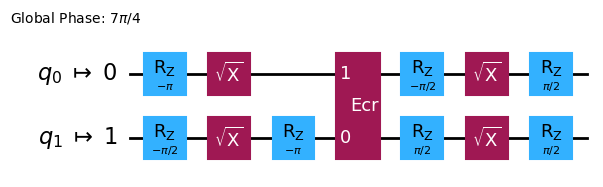

In [5]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
 
backend = service.least_busy(simulator=False, operational=True)
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

In [6]:
# Construct the Estimator instance.
 
estimator = Estimator(mode=backend)
estimator.options.resilience_level = 1
estimator.options.default_shots = 5000
 
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
 
# One pub, with one circuit to run against five different observables.
job = estimator.run([(isa_circuit, mapped_observables)])
 
# Use the job ID to retrieve your job data later
print(f">>> Job ID: {job.job_id()}")

>>> Job ID: d1r40mtx3st0008ykvt0


/home/caiosiq/.conda/envs/qpa_env/lib/python3.10/site-packages/qiskit_ibm_runtime/qiskit_runtime_service.py:1129: UserWarning: IBM Quantum Platform is moving, and this version will be sunset on July 1. To get started on the new platform, read the migration guide at https://docs.quantum.ibm.com/migration-guides/classic-iqp-to-cloud-iqp
  warnings.warn(warning_message)


In [ ]:
# Plot the result
 
from matplotlib import pyplot as plt
 
values = pub_result.data.evs
 
errors = pub_result.data.stds
 
# plotting graph
plt.plot(observables_labels, values, "-o")
plt.xlabel("Observables")
plt.ylabel("Values")
plt.show()